In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Keras has MNIST built-in. It downloads it and splits it into training and testing sets.
print("Loading MNIST Data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Original training data shape: {x_train.shape}")

Loading MNIST Data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data shape: (60000, 28, 28)


In [ ]:
print("\nPreprocessing Data...")
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


Preprocessing Data...


In [ ]:
# Normalize: Convert pixel values from 0-255 to floats between 0.0 and 1.0
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"New training data shape: {x_train.shape}")
# Output will be (60000, 28, 28, 1)

New training data shape: (60000, 28, 28, 1)



Plotting a sample image to verify...


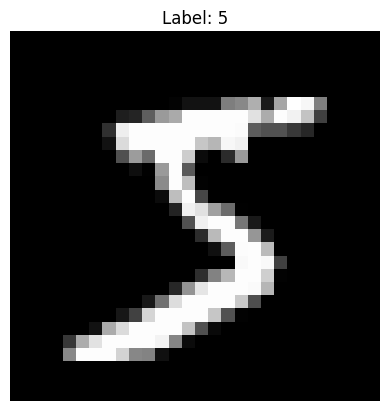

In [ ]:
print("\nPlotting a sample image to verify...")
sample_image = x_train[0]
sample_label = y_train[0]
# Matplotlib expects a 2D array for grayscale images, so we drop the channel dimension for plotting
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Label: {sample_label}")
plt.axis('off') # Hides the axis grid
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

print("Building the CNN Architecture...")

Building the CNN Architecture...


In [ ]:
# 1. Initialize the model
model = Sequential()

In [ ]:
# 2. Add the first Convolutional Layer (The Feature Detectors)
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Add the Max Pooling Layer (The Compressor)
model.add(MaxPooling2D(pool_size=(2, 2)))

In [ ]:
# 4. Add a second set of Conv/Pool layers to find more complex shapes
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

In [ ]:
# 4. Add a second set of Conv/Pool layers to find more complex shapes
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

In [ ]:
# 5. Flatten the 3D maps into a 1D vector
model.add(Flatten())

In [ ]:
# 6. Add the final decision-making layer
model.add(Dense(10, activation='softmax'))

In [ ]:
# 7. Compile the model (Give it a brain to learn)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print a summary of the network's layers and shapes
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,394 (220.29 KB)

 Trainable params: 56,394 (220.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8. Train the model!
print("\nStarting Training...")
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

print("\nTraining Complete!")


Starting Training...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9349 - loss: 0.2155 - val_accuracy: 0.9773 - val_loss: 0.0807
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9766 - loss: 0.0759 - val_accuracy: 0.9805 - val_loss: 0.0629
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9825 - loss: 0.0558 - val_accuracy: 0.9858 - val_loss: 0.0474
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.9865 - val_loss: 0.0516
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9882 - val_loss: 0.0461

Training Complete!


Installing the wiretap...


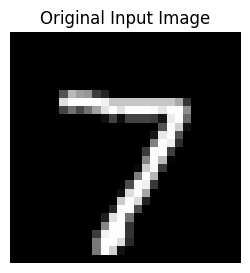

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

print("Installing the wiretap...")

# 1. Select a single image from the test set (The first image is a '7')
# We use [0:1] instead of [0] to keep the shape as (1, 28, 28, 1) instead of (28, 28, 1)
test_image = x_test[0:1]

# Draw the original image so we have a reference point
plt.figure(figsize=(3,3))
plt.imshow(test_image[0].squeeze(), cmap='gray')
plt.title("Original Input Image")
plt.axis('off')
plt.show()


In [ ]:
# 2. Build the "Wiretap" Sub-Model
# We use the main model's input, but stop the output at the very first layer (Layer 0)
extractor_model = Model(inputs=model.inputs, outputs=model.layers[0].output)

In [ ]:
# 3. Push the image through the Sub-Model (Inference)
print("\nPushing image through Layer 1...")
feature_maps = extractor_model.predict(test_image)

# Print the shape to prove we intercepted the data correctly
print(f"Shape of intercepted data: {feature_maps.shape}")


Pushing image through Layer 1...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Shape of intercepted data: (1, 26, 26, 32)



Plotting the 32 Feature Maps...


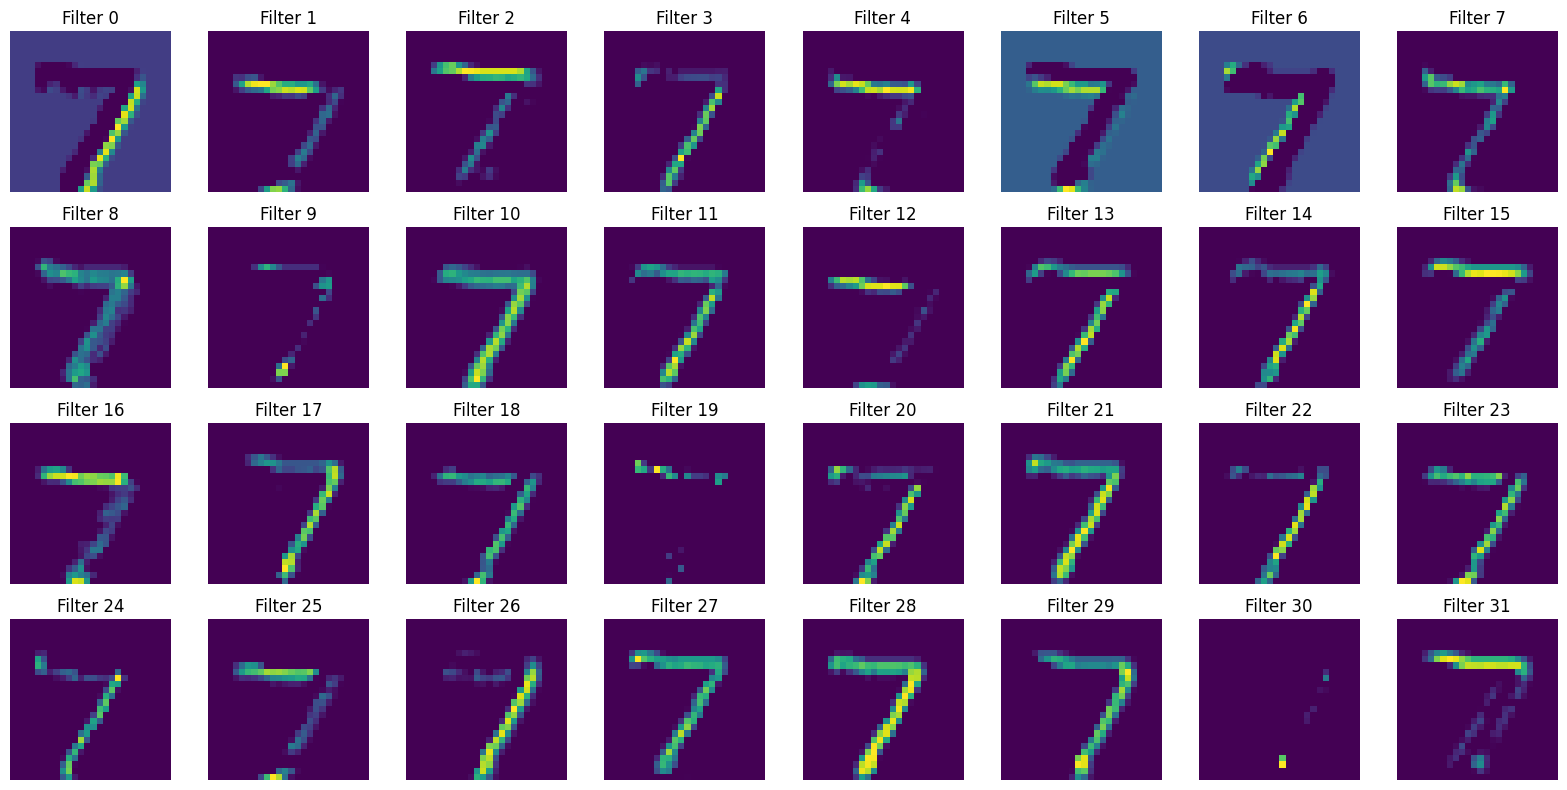

In [ ]:
# 4. Draw the 32 Feature Maps
print("\nPlotting the 32 Feature Maps...")
# Create a blank 4x8 grid to hold our 32 images
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

# Loop through all 32 filters and draw them on the grid
for i, ax in enumerate(axes.flat):
    # Slice out the 2D grid for filter 'i'
    # [0] is our single image, [:, :] grabs all height and width, [i] grabs the specific filter
    single_heatmap = feature_maps[0, :, :, i]

    # Draw it using the 'viridis' color map (dark purple = 0, bright yellow = high activation)
    ax.imshow(single_heatmap, cmap='viridis')
    ax.set_title(f"Filter {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
print("Extracting the raw filters (weights)...")

# 1. Access the first layer of our trained model
first_layer = model.layers[0]

Extracting the raw filters (weights)...


In [ ]:
# 2. Extract the weights and biases from this layer
# get_weights() returns a list containing two arrays: [weights_matrix, biases_array]
weights, biases = first_layer.get_weights()

In [ ]:
# 3. Print the shape to understand the math
print(f"Shape of the weight tensor: {weights.shape}")
# Expected output: (3, 3, 1, 32)

Shape of the weight tensor: (3, 3, 1, 32)


In [ ]:
# 4. Normalize the weights to be between 0.0 and 1.0 for visual plotting
w_min, w_max = weights.min(), weights.max()
weights_normalized = (weights - w_min) / (w_max - w_min)


Plotting the 32 Filter Weights (3x3 pixels each)...


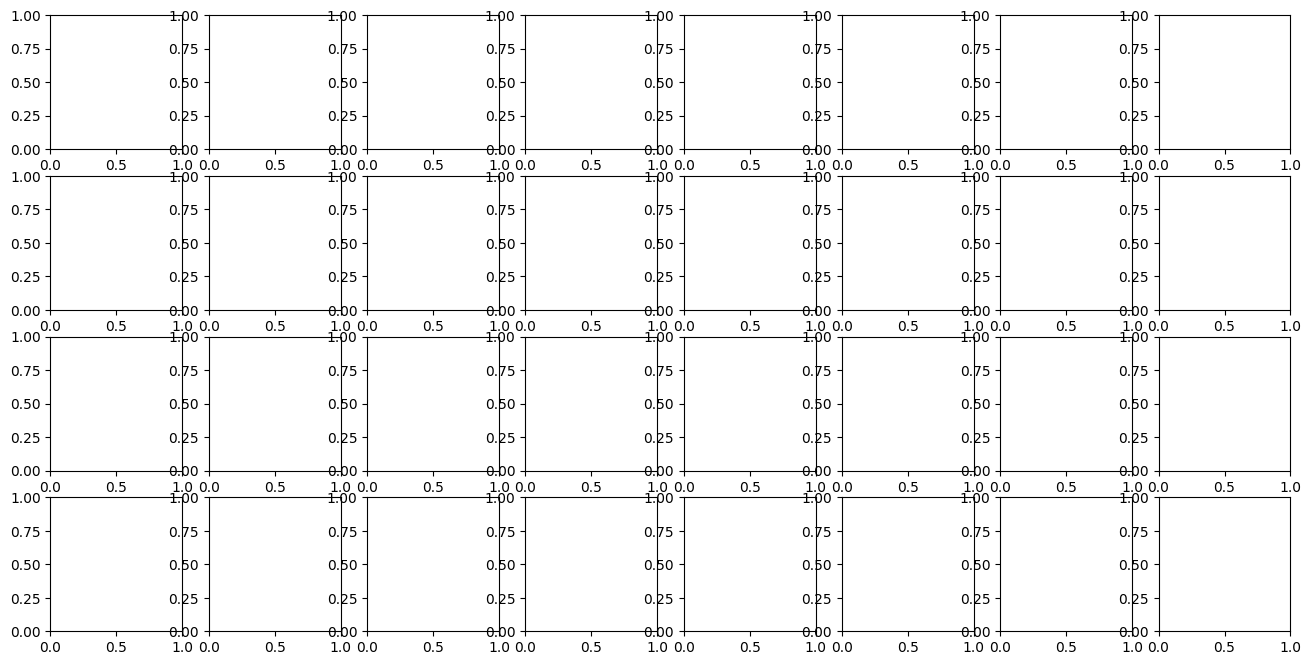

In [ ]:
# 5. Set up a 4x8 grid to draw the 32 filters
print("\nPlotting the 32 Filter Weights (3x3 pixels each)...")
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

In [ ]:
# 6. Loop through and draw each 3x3 filter
for i, ax in enumerate(axes.flat):
    # Slice out the 3x3 grid for filter 'i'
    # [All Rows, All Cols, Input Channel 0, Specific Filter i]
    single_filter = weights_normalized[:, :, 0, i]

    # Draw the 3x3 grid using a grayscale color map
    ax.imshow(single_filter, cmap='gray')
    ax.set_title(f"Filter {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print("Setting up the hallucination engine...")

# 1. Create a sub-model to extract the output of the first layer
extractor = tf.keras.Model(inputs=model.inputs, outputs=model.layers[0].output)


Setting up the hallucination engine...


In [ ]:
# 2. Define the exact math for Gradient Ascent
@tf.function
def compute_loss_and_grads(input_image, filter_index):
    # Start the calculus tape recorder
    with tf.GradientTape() as tape:
        tape.watch(input_image)

        # Push the image through the layer
        activations = extractor(input_image)

        # Isolate the specific filter we want to maximize
        filter_activation = activations[:, :, :, filter_index]

        # Calculate the average score (the "loss" we want to maximize)
        score = tf.reduce_mean(filter_activation)

    # Calculate exactly how to change the pixels to increase the score
    gradients = tape.gradient(score, input_image)

    # Normalize the gradients so the math stays stable
    gradients = tf.math.l2_normalize(gradients)

    return score, gradients

In [ ]:
# 3. Create a starting canvas of pure random noise
print("Generating starting canvas...")
# Shape: (1 image, 28 height, 28 width, 1 channel). Values between 0.4 and 0.6 (gray)
synthetic_image = tf.random.uniform((1, 28, 28, 1), minval=0.4, maxval=0.6)

Generating starting canvas...


In [ ]:
# 4. The Gradient Ascent Loop
filter_to_maximize = 0  # We will look at Filter #0
learning_rate = 10.0    # How big of a step we take each loop
iterations = 40         # How many times we tweak the image

print(f"Maximizing Filter {filter_to_maximize} over {iterations} iterations...")

for i in range(iterations):
    score, gradients = compute_loss_and_grads(synthetic_image, filter_to_maximize)

    # The Core Magic: Add the gradients to the image to mathematically increase the score
    synthetic_image = synthetic_image + (gradients * learning_rate)

Maximizing Filter 0 over 40 iterations...


In [ ]:
# 5. Clean up the final image for Matplotlib to draw it
final_image = synthetic_image.numpy()[0, :, :, 0]
final_image -= final_image.min() # Shift everything down to 0
final_image /= (final_image.max() + 1e-5) # Squeeze everything between 0.0 and 1.0

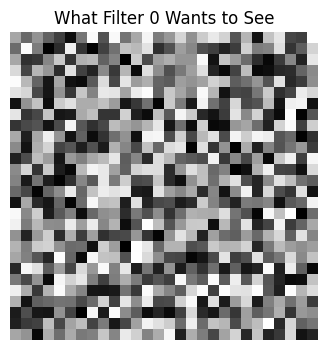

In [ ]:
# 6. Draw the hallucinated feature
plt.figure(figsize=(4, 4))
plt.imshow(final_image, cmap='gray')
plt.title(f"What Filter {filter_to_maximize} Wants to See")
plt.axis('off')
plt.show()

Generating Accuracy and Loss plots...


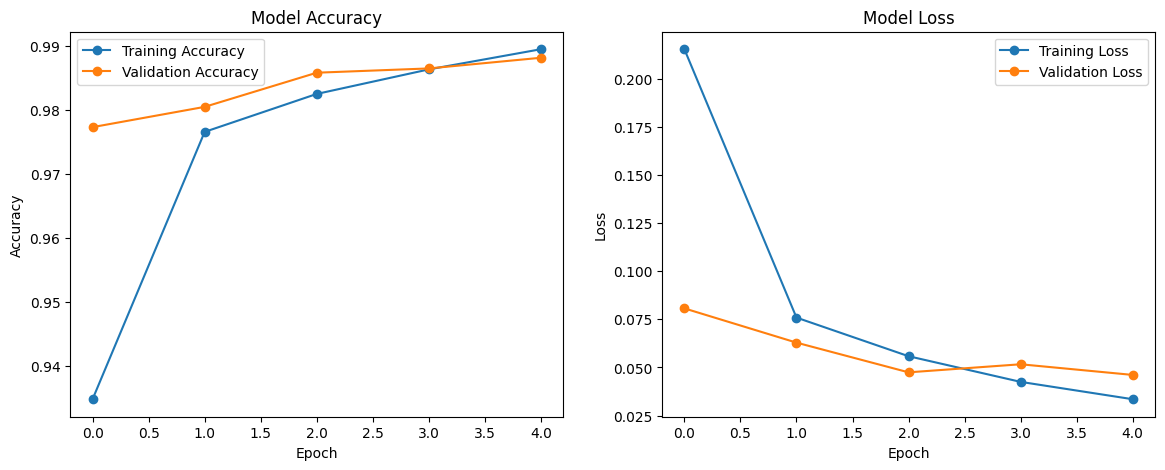


Running test data through the model to get predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Generating Confusion Matrix...


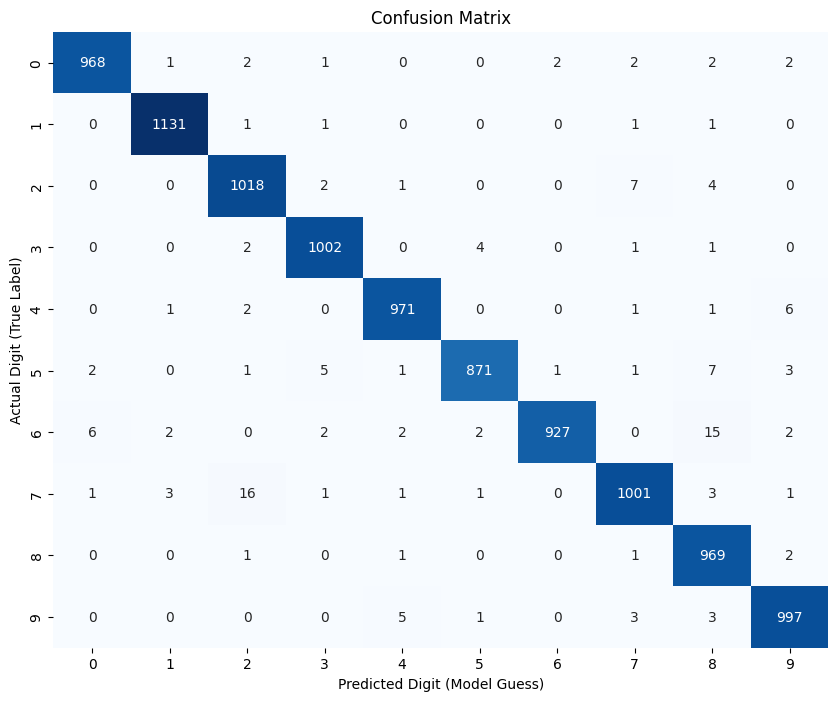


Generating Performance Heatmap...


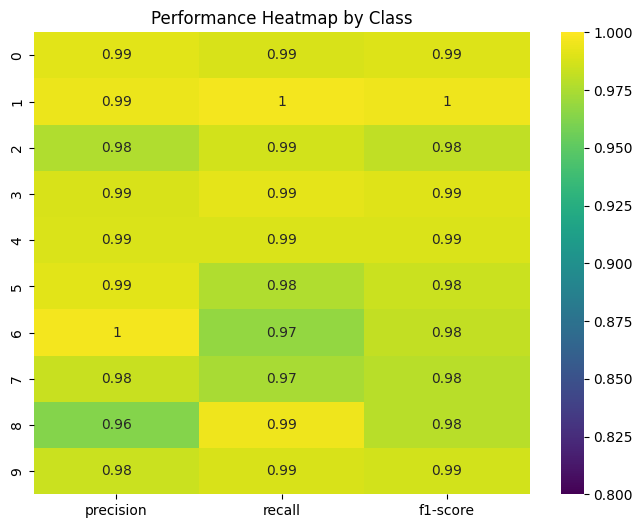

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# Graph 1 & 2: Training vs. Validation Accuracy and Loss
# ---------------------------------------------------------
print("Generating Accuracy and Loss plots...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Plot Loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.show()

# ---------------------------------------------------------
# Making Predictions for the Matrices
# ---------------------------------------------------------
print("\nRunning test data through the model to get predictions...")
# The model outputs 10 percentages per image. We want the index of the highest percentage.
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ---------------------------------------------------------
# Graph 3: The Confusion Matrix
# ---------------------------------------------------------
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
# sns.heatmap draws the matrix. 'annot=True' puts the numbers inside the boxes.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual Digit (True Label)')
plt.xlabel('Predicted Digit (Model Guess)')
plt.show()

# ---------------------------------------------------------
# Graph 4: Performance Heatmap (Precision, Recall, F1-Score)
# ---------------------------------------------------------
print("\nGenerating Performance Heatmap...")
# Generate the report as a dictionary so we can plot it
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to a Pandas DataFrame and drop the overall accuracy/support columns for a cleaner plot
report_df = pd.DataFrame(report_dict).iloc[:-1, :10].T

plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True, cmap='viridis', vmin=0.8, vmax=1.0)
plt.title('Performance Heatmap by Class')
plt.show()

Finding where the model made mistakes...
Total misclassified images out of 10,000: 145


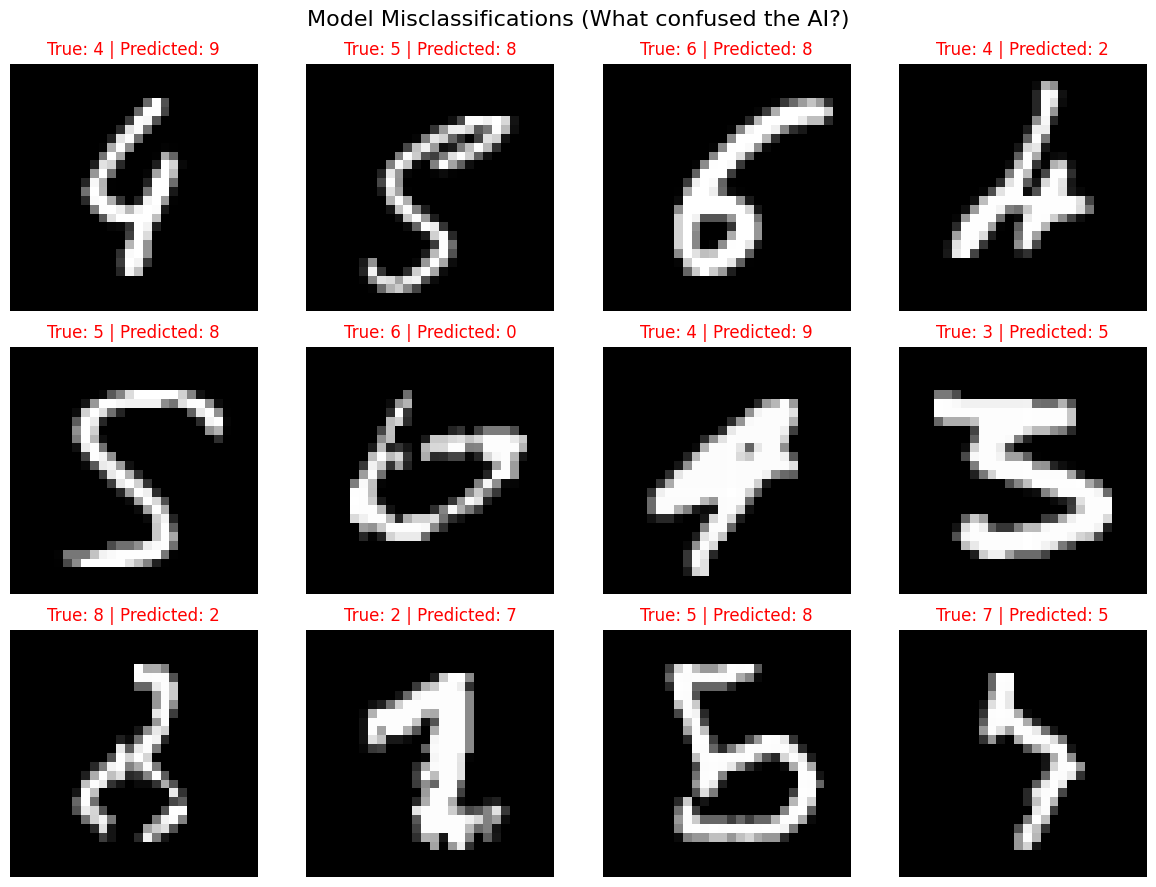


Extracting physical weights from Layer 1...


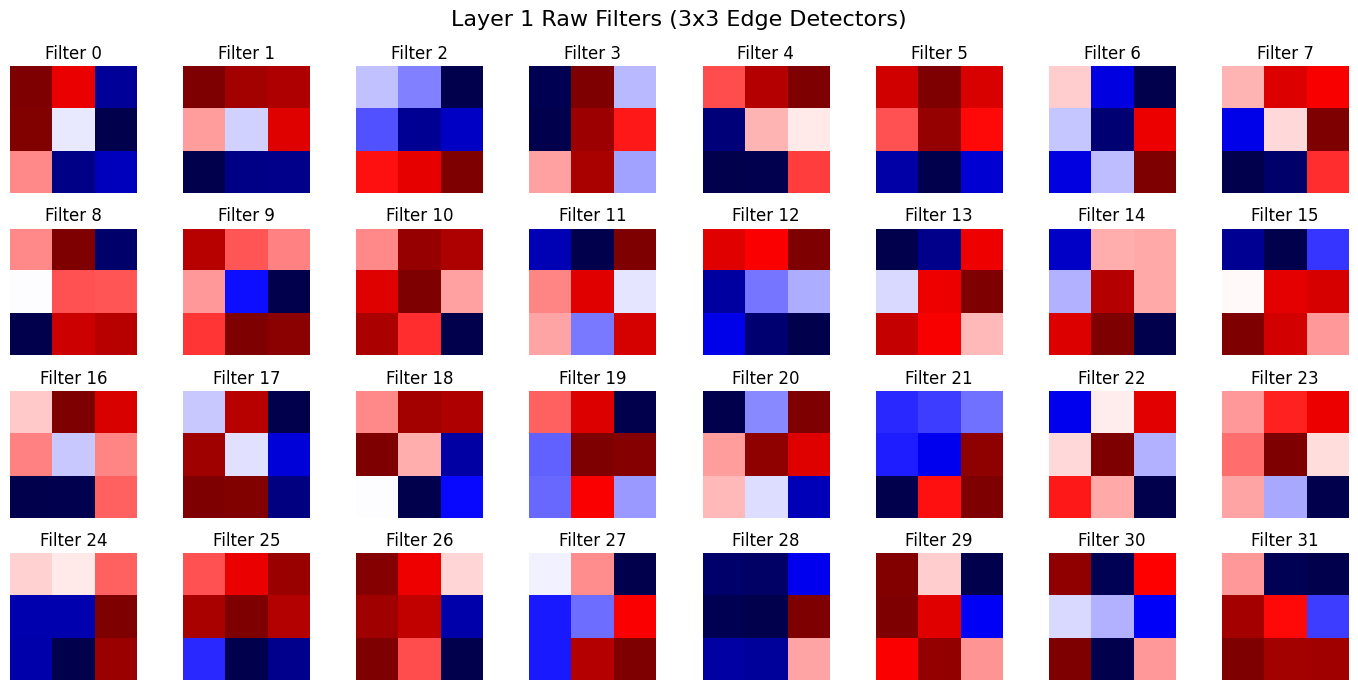


Extracting deep features and running t-SNE (This may take 15-30 seconds)...
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


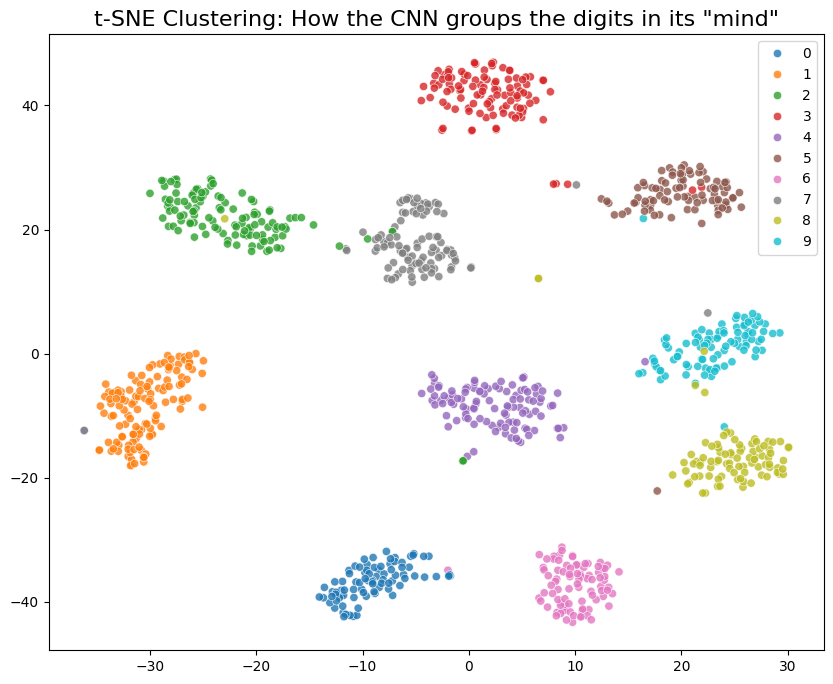

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model

# =========================================================
# 1. The Misclassification Grid (Error Analysis)
# =========================================================
print("Finding where the model made mistakes...")

# Find all indices where the prediction does not match the true label
incorrect_indices = np.where(y_pred != y_test)[0]
print(f"Total misclassified images out of 10,000: {len(incorrect_indices)}")

plt.figure(figsize=(12, 9))
# Plot the first 12 mistakes
for i, idx in enumerate(incorrect_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"True: {y_test[idx]} | Predicted: {y_pred[idx]}", color='red')
    plt.axis('off')

plt.suptitle("Model Misclassifications (What confused the AI?)", fontsize=16)
plt.tight_layout()
plt.show()

# =========================================================
# 2. Visualizing the Raw Filters / Weights (Phase 4)
# =========================================================
print("\nExtracting physical weights from Layer 1...")

# Extract weights from the first Conv2D layer
# get_weights() returns two things: the filters [0] and the biases [1]
filters, biases = model.layers[0].get_weights()

# The shape of filters is (3, 3, 1, 32) -> (height, width, channels, num_filters)
plt.figure(figsize=(14, 7))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    # Grab the 3x3 grid for the i-th filter
    single_filter = filters[:, :, 0, i]

    # Plot it. We use a diverging colormap (seismic) so 0 is white, negatives are blue, positives are red
    plt.imshow(single_filter, cmap='seismic')
    plt.title(f"Filter {i}")
    plt.axis('off')

plt.suptitle("Layer 1 Raw Filters (3x3 Edge Detectors)", fontsize=16)
plt.tight_layout()
plt.show()

# =========================================================
# 3. t-SNE Clustering (The "Brain Map")
# =========================================================
print("\nExtracting deep features and running t-SNE (This may take 15-30 seconds)...")

# Create a sub-model that outputs the data right BEFORE the final decision
# We tap into the 'Flatten' layer, which is usually layer index -2
feature_extractor = Model(inputs=model.inputs, outputs=model.layers[-2].output)

# To save time, we will only run t-SNE on the first 1,000 test images
subset_x = x_test[:1000]
subset_y = y_test[:1000]

# Push the images through to get the flattened feature vectors
deep_features = feature_extractor.predict(subset_x)

# Run the t-SNE algorithm to squash the data down to 2 dimensions (X and Y coordinates)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(deep_features)

# Plot the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=subset_y,
    palette=sns.color_palette("tab10", 10), # 10 distinct colors for 10 digits
    legend="full",
    alpha=0.8
)
plt.title('t-SNE Clustering: How the CNN groups the digits in its "mind"', fontsize=16)
plt.show()


Finding correct predictions and their confidence levels...


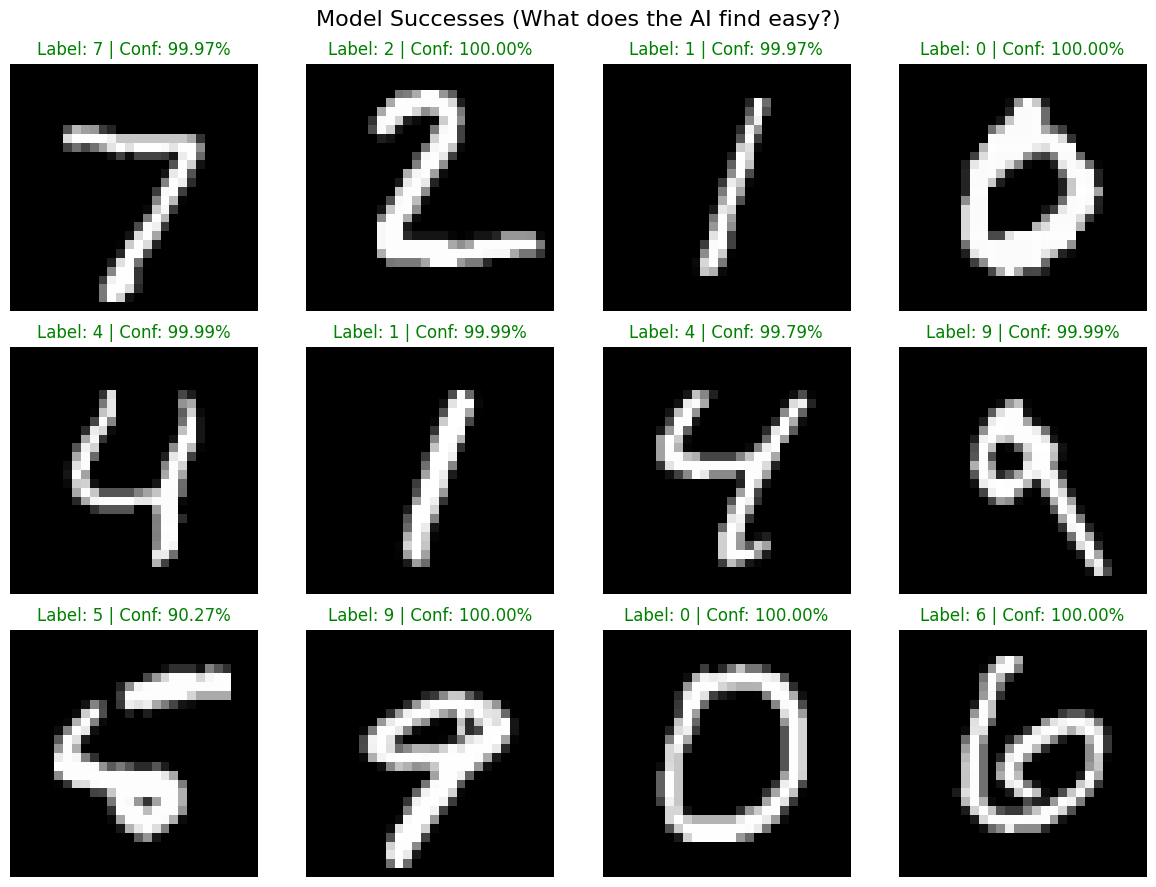

In [ ]:
# =========================================================
# 4. Correct Predictions with Confidence Scores
# =========================================================
print("\nFinding correct predictions and their confidence levels...")

# Find all indices where the prediction MATCHES the true label
correct_indices = np.where(y_pred == y_test)[0]

plt.figure(figsize=(12, 9))
# Plot the first 12 correct guesses
for i, idx in enumerate(correct_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')

    # Extract how confident the model was (multiply by 100 for a percentage)
    confidence = np.max(y_pred_probs[idx]) * 100

    # Color the text green to indicate success
    plt.title(f"Label: {y_test[idx]} | Conf: {confidence:.2f}%", color='green')
    plt.axis('off')

plt.suptitle("Model Successes (What does the AI find easy?)", fontsize=16)
plt.tight_layout()
plt.show()